In [26]:
import pandas as pd

path = "../data/raw"

df_test = pd.read_csv(
    f"{path}/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
)

print(df_test.shape)

df_test.head()

(35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [27]:
print(df_test.dtypes)

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object


In [28]:
print(df_test.isna().sum())

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64


In [29]:
import glob

files = glob.glob(f"{path}/PRSA_Data_*.csv")
print(len(files))

12


In [30]:
df_list = [pd.read_csv(f) for f in files]
df = pd.concat(df_list, ignore_index=True)
print(df.shape)

(420768, 18)


In [31]:
print(df['station'].unique())

<StringArray>
[ 'Aotizhongxin',     'Changping',      'Dingling',        'Dongsi',
      'Guanyuan',       'Gucheng',       'Huairou',  'Nongzhanguan',
        'Shunyi',       'Tiantan',        'Wanliu', 'Wanshouxigong']
Length: 12, dtype: str


In [32]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.drop(columns=['year', 'month', 'day', 'hour', 'No'])
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)
print(df.shape)
df.head()

(420768, 14)


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [33]:
print(df.isna().sum())
print((df.isna().mean() * 100).round(2))

PM2.5        8739
PM10         6449
SO2          9021
NO2         12116
CO          20701
O3          13277
TEMP          398
PRES          393
DEWP          403
RAIN          390
wd           1822
WSPM          318
station         0
datetime        0
dtype: int64
PM2.5       2.08
PM10        1.53
SO2         2.14
NO2         2.88
CO          4.92
O3          3.16
TEMP        0.09
PRES        0.09
DEWP        0.10
RAIN        0.09
wd          0.43
WSPM        0.08
station     0.00
datetime    0.00
dtype: float64


In [34]:
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df[pollutant_cols] = df.groupby('station')[pollutant_cols].transform(
    lambda x: x.interpolate(limit=6, limit_direction='both')
)

print(df.isna().sum())

PM2.5        2471
PM10         1653
SO2          2977
NO2          4467
CO          10458
O3           4028
TEMP            0
PRES            0
DEWP            0
RAIN            0
wd           1822
WSPM            0
station         0
datetime        0
dtype: int64


In [35]:
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.ffill(limit=6))
print(df['wd'].isna().sum())

8


In [36]:
print(df.dropna().shape)

(404364, 14)


In [37]:

before = df.shape[0]
df = df.dropna().reset_index(drop=True)
after = df.shape[0]
print(f"Dropped {before - after} rows ({(before-after)/before*100:.2f}%)")
print(df.shape)

# Step 10: Sanity check - make sure values look physically reasonable
print(df.describe())
print(df['wd'].unique())
print(df.isna().sum().sum())  # should be 0

# Step 11: Save the cleaned dataset
df.to_csv("../data/beijing_air_quality_cleaned.csv", index=False)
print("Saved.")

Dropped 16404 rows (3.90%)
(404364, 14)
               PM2.5           PM10            SO2            NO2  \
count  404364.000000  404364.000000  404364.000000  404364.000000   
mean       79.758548     104.877715      15.704528      50.489051   
min         2.000000       2.000000       0.285600       1.026500   
25%        20.000000      36.000000       2.000000      23.000000   
50%        55.000000      82.000000       7.000000      43.000000   
75%       111.000000     145.000000      19.000000      71.000000   
max       999.000000     999.000000     500.000000     290.000000   
std        81.190660      92.713467      21.551034      35.244531   

                  CO             O3           TEMP           PRES  \
count  404364.000000  404364.000000  404364.000000  404364.000000   
mean     1233.324068      57.098101      13.488581    1010.802377   
min       100.000000       0.214200     -19.900000     982.400000   
25%       500.000000      10.000000       3.100000    1002.300

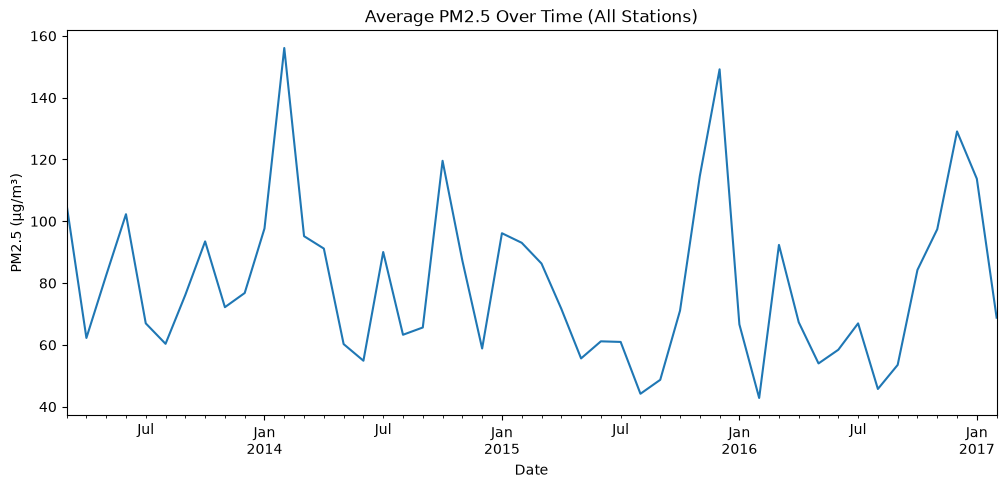

In [38]:
import matplotlib.pyplot as plt

df_monthly = df.set_index('datetime').resample('ME')['PM2.5'].mean()
df_monthly.plot(figsize=(12,5), title="Average PM2.5 Over Time (All Stations)")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Date")
plt.show()

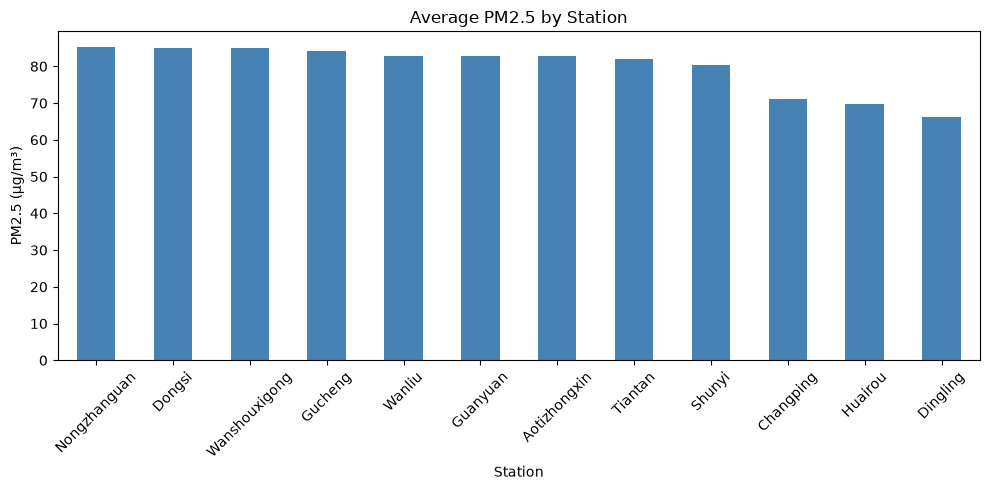

In [39]:
station_avg = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
station_avg.plot(kind='bar', figsize=(10,5), title="Average PM2.5 by Station", color='steelblue')
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Station")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

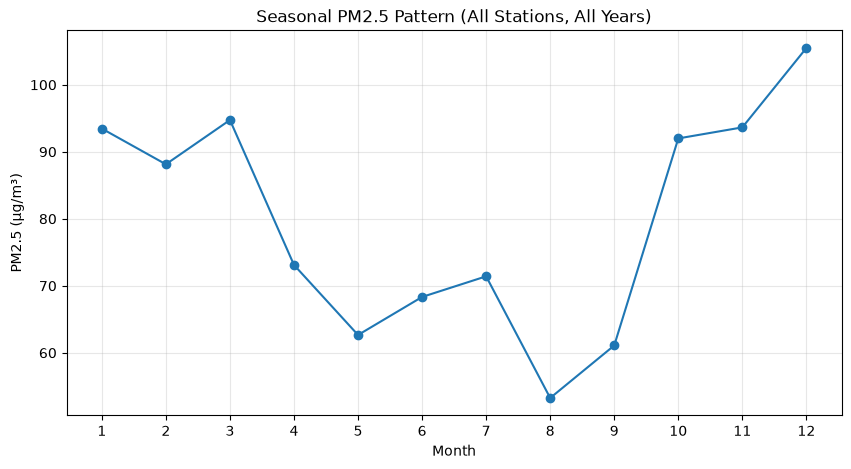

In [40]:
df['month'] = df['datetime'].dt.month
monthly_avg = df.groupby('month')['PM2.5'].mean()
monthly_avg.plot(kind='line', marker='o', figsize=(10,5), title="Seasonal PM2.5 Pattern (All Stations, All Years)")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.show()

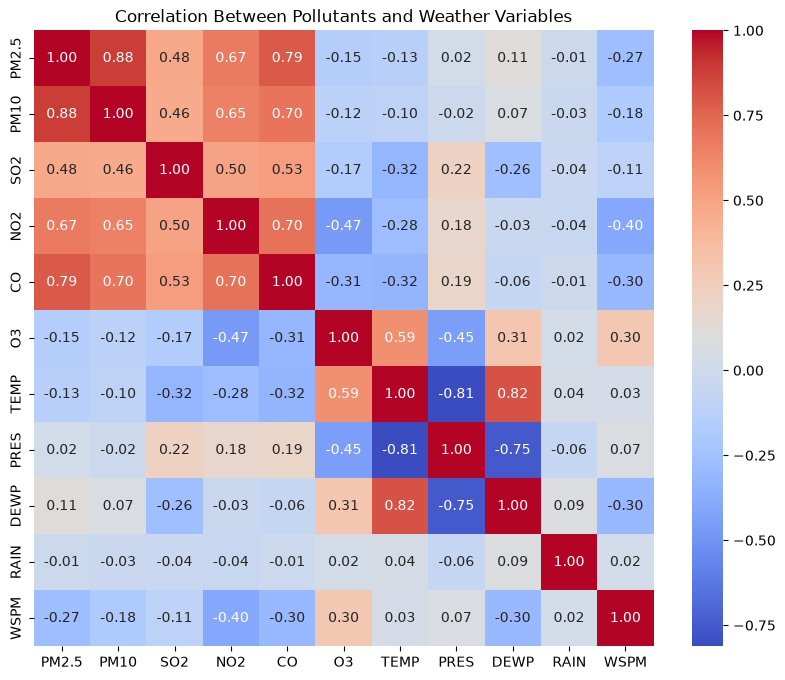

In [41]:
import seaborn as sns

corr = df[['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Pollutants and Weather Variables")
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [43]:
df_model = pd.get_dummies(df, columns=['station', 'wd'], drop_first=True)
print(df_model.shape)
df_model.head()

(404364, 39)


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,...,True,False,False,False,False,False,False,False,False,False
1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,...,False,False,False,False,False,False,False,False,False,False
2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,...,True,False,False,False,False,False,False,False,False,False
3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,...,False,True,False,False,False,False,False,False,False,False
4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,...,False,False,False,False,False,False,False,False,False,False


In [44]:
X = df_model.drop(columns=['PM2.5', 'datetime'])
y = df_model['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(323491, 37) (80873, 37)


In [45]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [46]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [47]:
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Linear Regression -> MAE:", round(lr_mae, 2), " R²:", round(lr_r2, 3))
print("Random Forest      -> MAE:", round(rf_mae, 2), " R²:", round(rf_r2, 3))

Linear Regression -> MAE: 20.4  R²: 0.856
Random Forest      -> MAE: 11.14  R²: 0.946


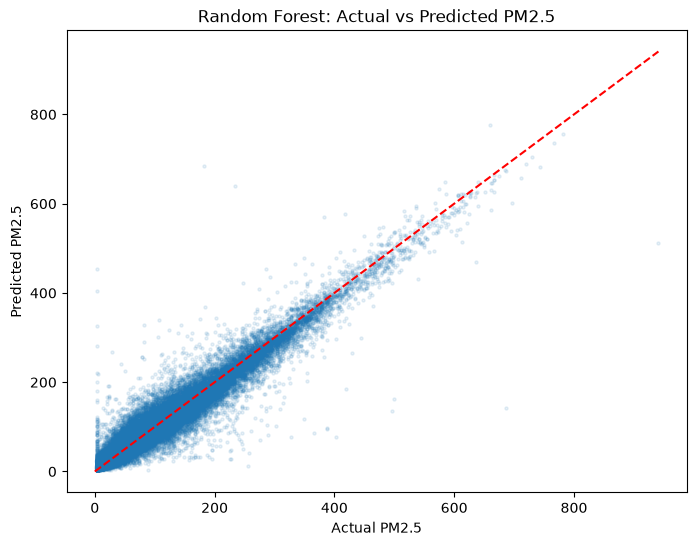

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_preds, alpha=0.1, s=5)
plt.plot([0, y_test.max()], [0, y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest: Actual vs Predicted PM2.5")
plt.show()

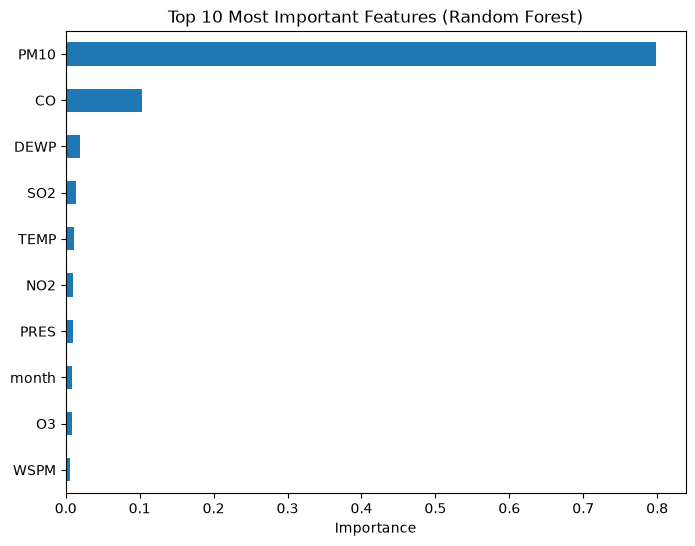

In [49]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', figsize=(8,6), title="Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [50]:
weather_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'month'] + [c for c in df_model.columns if c.startswith('station_') or c.startswith('wd_')]

X2 = df_model[weather_cols]
y2 = df_model['PM2.5']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model2.fit(X2_train, y2_train)
rf_preds2 = rf_model2.predict(X2_test)

print("Weather-only Random Forest -> MAE:", round(mean_absolute_error(y2_test, rf_preds2), 2),
      " R²:", round(r2_score(y2_test, rf_preds2), 3))

Weather-only Random Forest -> MAE: 21.26  R²: 0.804


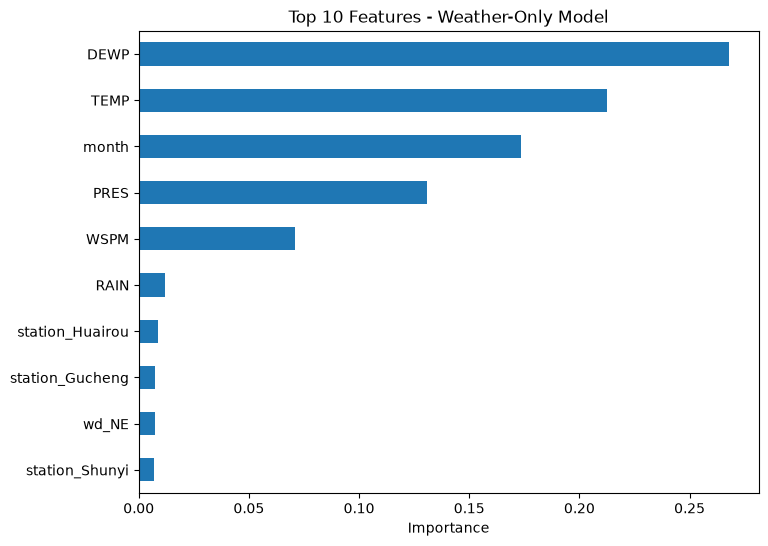

In [51]:
importances2 = pd.Series(rf_model2.feature_importances_, index=X2_train.columns).sort_values(ascending=False)
importances2.head(10).plot(kind='barh', figsize=(8,6), title="Top 10 Features - Weather-Only Model")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [54]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained models
joblib.dump(rf_model, "../models/rf_full_features.pkl")
joblib.dump(rf_model2, "../models/rf_weather_only.pkl")

print("Models saved successfully!")

Models saved successfully!
